In [6]:
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_contrastive_1.npz"
EMBEDDING_MODEL_PATH = "mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_contrastive_1.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]


# pairwise distances
from scipy.spatial.distance import pdist, squareform
distances = pdist(_embeddings, metric="euclidean")

max_distance = np.max(distances)
min_distance = np.min(distances)
average_distance = np.mean(distances)

diff = max_distance - min_distance
y = diff / min_distance

print(f"Max distance: {max_distance}")
print(f"Min distance: {min_distance}")
print(f"Difference: {diff}")
print(f"Difference / Min distance: {y}")
print(f"Average distance: {average_distance}")

Max distance: 9.430112678034757
Min distance: 0.0
Difference: 9.430112678034757
Difference / Min distance: inf
Average distance: 3.3256957616713163


C:\Users\milob\AppData\Local\Temp\ipykernel_27744\704161853.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  y = diff / min_distance


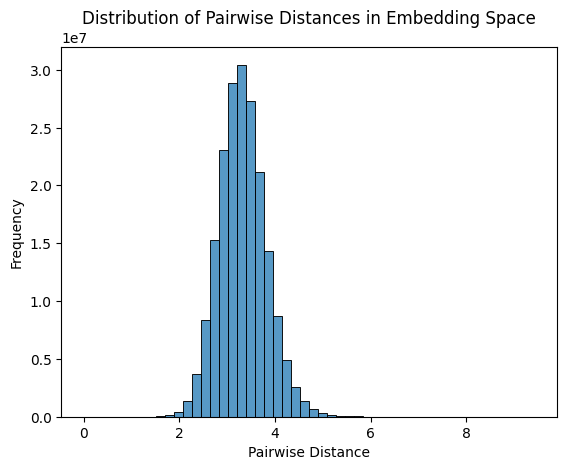

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(distances, bins=50, kde=False)
plt.xlabel("Pairwise Distance")
plt.ylabel("Frequency") 
plt.title("Distribution of Pairwise Distances in Embedding Space")
plt.show()

Dimension 0: Mean = -0.1250, Std Dev = 0.3566
Dimension 1: Mean = 0.3919, Std Dev = 0.5477
Dimension 2: Mean = -0.7310, Std Dev = 0.4018
Dimension 3: Mean = 0.4715, Std Dev = 0.4036
Dimension 4: Mean = 0.2843, Std Dev = 0.3473
Dimension 5: Mean = 0.2015, Std Dev = 0.3952
Dimension 6: Mean = 0.2494, Std Dev = 0.3923
Dimension 7: Mean = -0.1491, Std Dev = 0.3970
Dimension 8: Mean = 0.4477, Std Dev = 0.3848
Dimension 9: Mean = -0.9756, Std Dev = 0.4067
Dimension 10: Mean = 0.1462, Std Dev = 0.6483
Dimension 11: Mean = 0.7282, Std Dev = 0.4097
Dimension 12: Mean = -0.3196, Std Dev = 0.3496
Dimension 13: Mean = -0.1905, Std Dev = 0.4257
Dimension 14: Mean = -0.1325, Std Dev = 0.3929
Dimension 15: Mean = -0.1829, Std Dev = 0.3922
Dimension 16: Mean = -0.1903, Std Dev = 0.3709
Dimension 17: Mean = -0.0588, Std Dev = 0.5254
Dimension 18: Mean = 0.2318, Std Dev = 0.3868
Dimension 19: Mean = -0.6339, Std Dev = 0.4338
Dimension 20: Mean = 0.1129, Std Dev = 0.3714
Dimension 21: Mean = -0.7146, Std

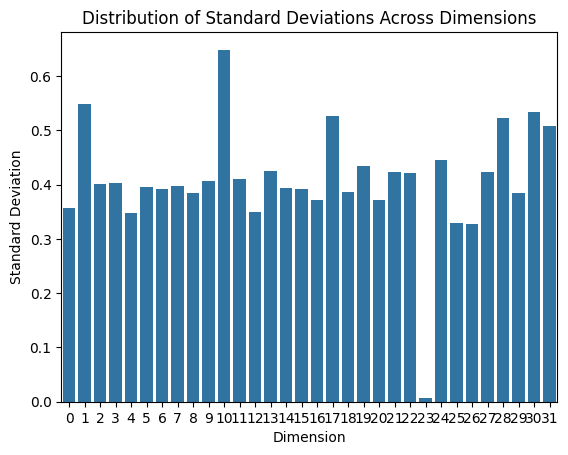

In [8]:
# for each dimention calculate the mean and std_deviation
for i in range(_embeddings.shape[1]):
    dim_values = _embeddings[:, i]
    mean = np.mean(dim_values)
    std_dev = np.std(dim_values)
    print(f"Dimension {i}: Mean = {mean:.4f}, Std Dev = {std_dev:.4f}")
    
# make a barplot of the std_deviation of each dimension
std_devs = [np.std(_embeddings[:, i]) for i in range(_embeddings.shape[1])]
sns.barplot(x=list(range(len(std_devs))), y=std_devs)
plt.xlabel("Dimension")
plt.ylabel("Standard Deviation")
plt.title("Distribution of Standard Deviations Across Dimensions")
plt.show()

Autovalori: [5.97170904e-01 5.29990591e-01 3.68764770e-01 2.24599141e-05
 2.46669121e-01 2.16569155e-01 9.31009555e-02 9.67096478e-02
 1.91579579e-01 1.89409566e-01 1.02375921e-01 1.06632312e-01
 1.84023415e-01 1.13772016e-01 1.74110508e-01 1.69757174e-01
 1.68085650e-01 1.64245760e-01 1.19681354e-01 1.58895267e-01
 1.23769172e-01 1.26072561e-01 1.27954389e-01 1.30401072e-01
 1.32922513e-01 1.55097405e-01 1.37143629e-01 1.39850089e-01
 1.51518391e-01 1.42956938e-01 1.48650104e-01 1.46328220e-01]


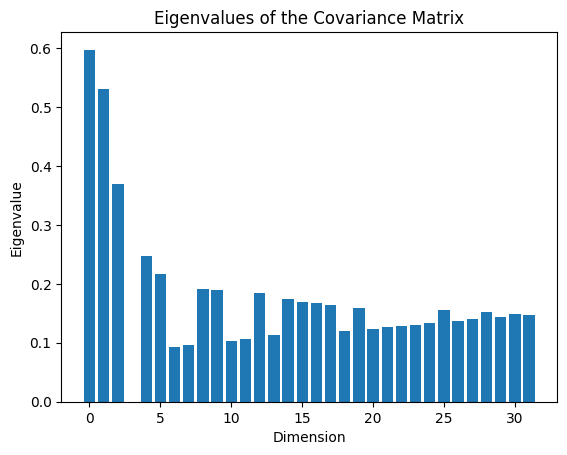

In [9]:
# covariance matrix and eigenvalues
cov_matrix = np.cov(_embeddings, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Autovalori:", eigenvalues)

# bar plot of eigenvalues
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.xlabel("Dimension")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of the Covariance Matrix")
plt.show()

In [16]:
# generate a track with seed 100 
import requests
import random
import numpy as np
import copy


randomizer = random.Random(100)

def generate_track(seed, randomizer):
    response = requests.post(
                    f"http://localhost:4242/generate",
                    json={
                        "id": seed,
                        "mode": "voronoi",
                        "trackSize": randomizer.randint(4, 10),
                        "rngMode": 1
                    },
                    timeout=60
                )
    
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")
    
    sol = response.json()
    response = requests.post(
                    f"http://localhost:4242/reconstruct",
                    json=sol,
                    timeout=60
                )
    
    sol = response.json()              
    sol["rngMode"] = "perlin" 
    return sol

def eval_track(sol):
    #use sol as json + add getTraces = true parameter
    copy_sol = copy.deepcopy(sol)  # create a deep copy of the original sol
    copy_sol["getTraces"] = True
    # remove track from copy_sol to save bandwidth
    if "track" in copy_sol:
        del copy_sol["track"]
    
    response = requests.post(
                    f"http://localhost:4242/evaluate",
                    json=copy_sol
                    ,
                    timeout=60
                )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")
          
    r_json = response.json()    
    return r_json.get("fitness", {})

sol = generate_track(100, randomizer)
track = sol.get("track", {})
print(sol.keys())

fit = eval_track(sol)
print(f"Fitness: {fit}")
embedding = fit.get("embedding_data", [])
nparray_embedding = np.array(embedding)
print(nparray_embedding.shape)

dict_keys(['mode', 'track', 'splineVector', 'trackSize', 'dataSet', 'edges', 'selectedCells', 'rngMode'])
Fitness: {'length': 2276.020996, 'deltaX': 0.0009, 'deltaY': 0.000732, 'deltaAngleDegrees': 0.000236, 'speed_entropy': 4.578809616299319, 'acceleration_entropy': 2.2814993014153875, 'braking_entropy': 1.16520559498409, 'positions_mean': 0, 'avg_radius_mean': 186.16546434782612, 'gaps_mean': 2.4519994166666668, 'right_bends': 19, 'avg_radius_var': 48630.092948182755, 'total_overtakes': 5.25, 'straight_sections': 19, 'gaps_var': 0.9280446556510556, 'left_bends': 17, 'positions_var': 3.25, 'curvature_entropy': 3.5687751248602413, 'lap_times': 0, 'embedding_data': [[0, 52.9013, 0.00929683, 1, 0, 4, 16.0018], [1, 53.6971, 0.0173433, 1, 0, 4, 16.0063], [2, 54.4728, 0.0286977, 1, 0, 4, 15.9745], [3, 55.2195, 0.0422184, 1, 0, 4, 15.815], [4, 55.0599, 0.069115, 0, 0.515225, 4, 15.1053], [5, 52.1425, 0.0651467, 0, 0.484887, 4, 13.9485], [6, 49.5946, 0.0981268, 0.10004, 0, 4, 12.5974], [7, 46

In [17]:
import copy
import umap
import matplotlib.pyplot as plt

from mapelite.evaluator import EvaluatorMetrics


def measures_from_metrics(array_of_data, evaluator):
    return [evaluator.measure_from_metrics(data) for data in array_of_data]

def cleanup_metrics(evaluator, array_of_data):
    return [evaluator.preprocessor(metrics) for metrics in array_of_data]


def roll_samples_by_percent(embedding_data, percent=0.25):
    if not 0 <= percent <= 1:
        raise ValueError("percent must be between 0 and 1")

    num_samples = embedding_data.shape[0]
    shift = int(num_samples * percent)
    return np.roll(embedding_data, shift=shift, axis=0), shift

# 1) Load evaluator and train UMAP on the precomputed embedding space (_embeddings)
evaluator = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)
umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model.fit(_embeddings)



Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_contrastive_1.pth...
Model loaded with latent_dim=32


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


(298, 7)


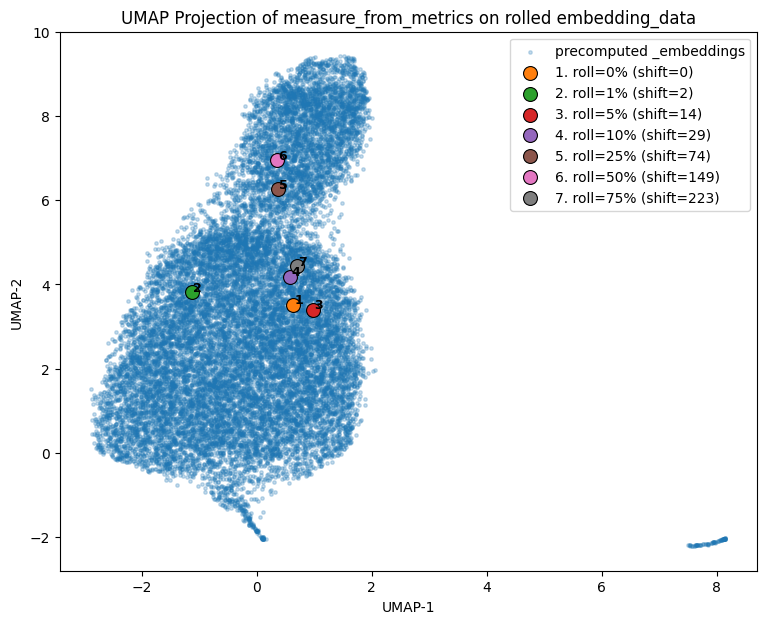

1. roll=0% (shift=0) -> (0.6357, 3.5189)
2. roll=1% (shift=2) -> (-1.1200, 3.8123)
3. roll=5% (shift=14) -> (0.9832, 3.4039)
4. roll=10% (shift=29) -> (0.5875, 4.1869)
5. roll=25% (shift=74) -> (0.3725, 6.2727)
6. roll=50% (shift=149) -> (0.3549, 6.9481)
7. roll=75% (shift=223) -> (0.7015, 4.4422)


In [18]:
# 2) Build several rolled versions of the same embedding_data
roll_percents = [0.00, 0.01, 0.05, 0.10, 0.25, 0.5, 0.75]
rolled_datasets = []
labels = []

print(nparray_embedding.shape)
for p in roll_percents:
    rolled_data, shift = roll_samples_by_percent(nparray_embedding, percent=p)
    rolled_datasets.append(rolled_data)
    labels.append(f"roll={int(p * 100)}% (shift={shift})")

# 3) Convert each rolled metric sequence into a measure embedding
measure_embeddings = np.array(measures_from_metrics(rolled_datasets, evaluator))
cleaned_metrics = np.array(cleanup_metrics(evaluator, rolled_datasets))

# 4) Project those embeddings into the UMAP space trained on _embeddings
projected_points = umap_model.transform(measure_embeddings)

# 5) Plot for visual comparison
base_projection = umap_model.transform(_embeddings)

plt.figure(figsize=(9, 7))
plt.scatter(base_projection[:, 0], base_projection[:, 1], s=6, alpha=0.25, label="precomputed _embeddings")

for i, label in enumerate(labels):
    point_number = i + 1
    x, y = projected_points[i, 0], projected_points[i, 1]
    plt.scatter(x, y, s=100, edgecolor="black", linewidth=0.8, label=f"{point_number}. {label}")
    plt.text(x + 0.02, y + 0.02, str(point_number), fontsize=9, weight="bold")

plt.title("UMAP Projection of measure_from_metrics on rolled embedding_data")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.show()

for idx, (label, point) in enumerate(zip(labels, projected_points), start=1):
    print(f"{idx}. {label} -> ({point[0]:.4f}, {point[1]:.4f})")

In [19]:
trace_data = {
            "speed_trace": fit.get("speed_trace", None),
            "steer_trace": fit.get("steer_trace", None),
            "brake_trace": fit.get("brake_trace", None),
            "accel_trace": fit.get("accel_trace", None),
            "border_dist_trace": fit.get("border_dist_trace", None),
        }

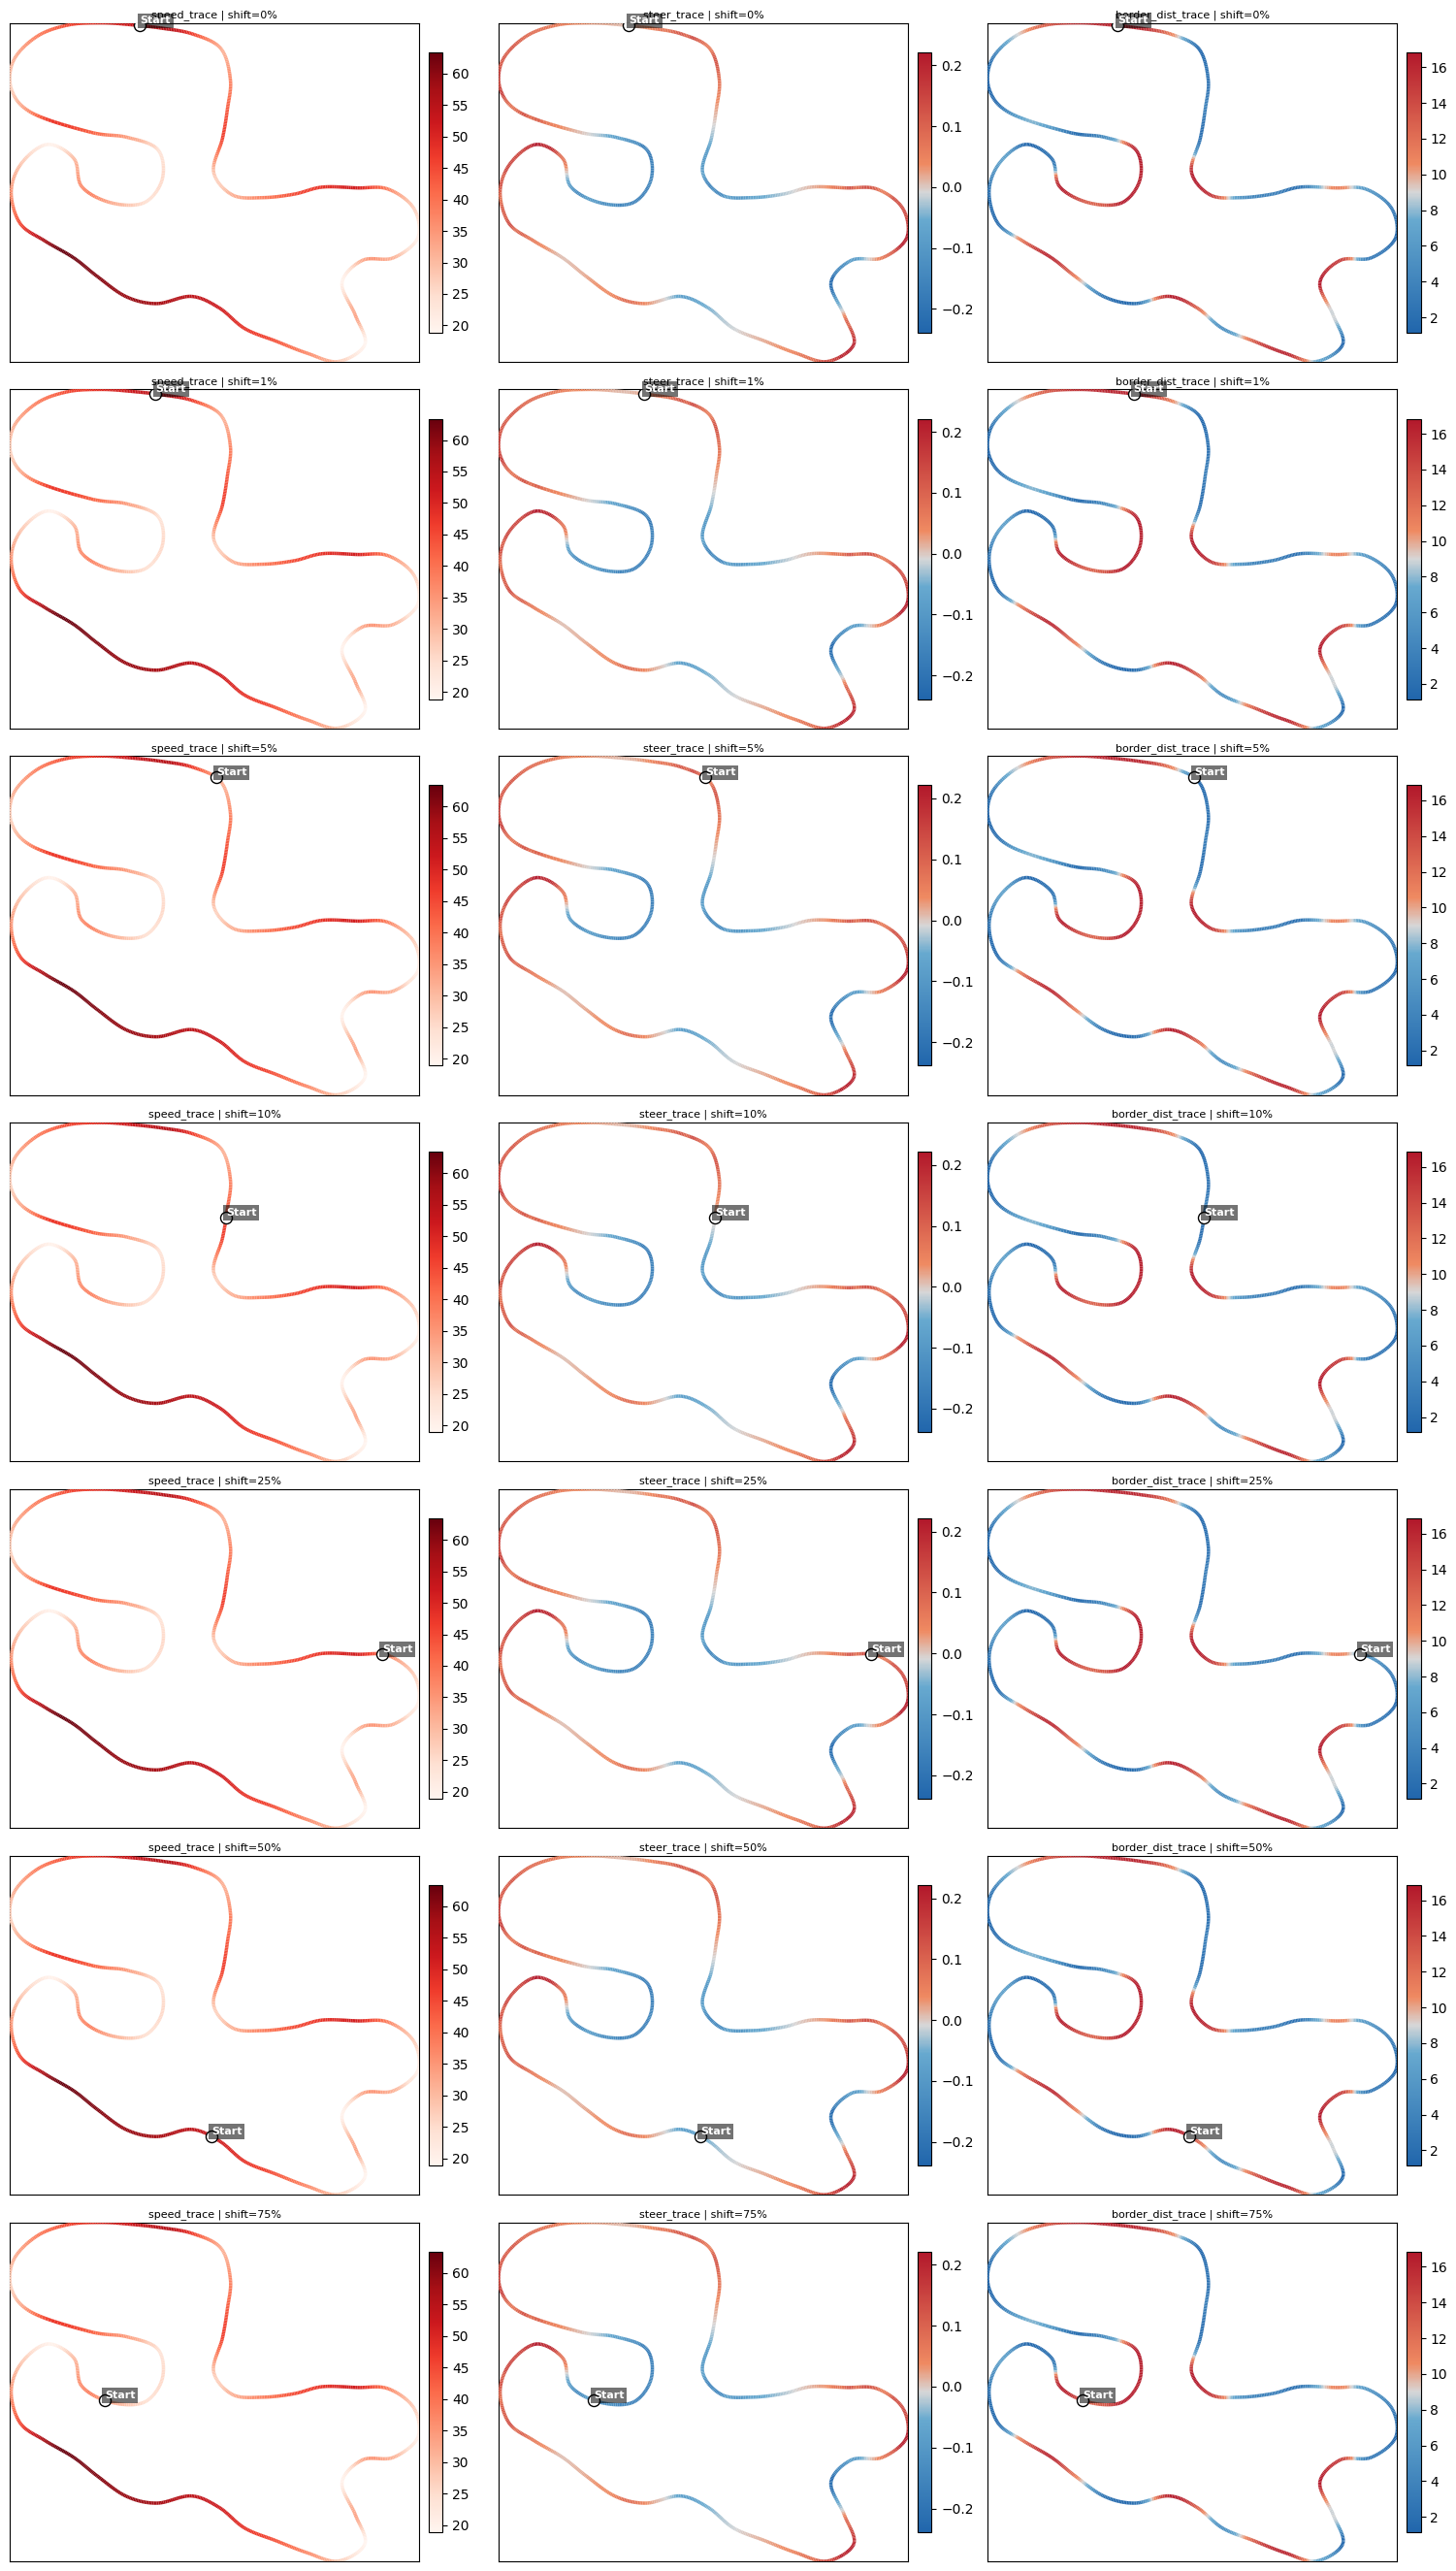

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from mapelite.data_analysis.utils import plot_track_heatmap
except ImportError:
    from utils import plot_track_heatmap

CUSTOM_BURD = LinearSegmentedColormap.from_list(
    "custom_burd",
    [
        (0.0, (33 / 255.0, 102 / 255.0, 172 / 255.0)),
        (0.4, (103 / 255.0, 169 / 255.0, 207 / 255.0)),
        (0.5, (215 / 255.0, 215 / 255.0, 215 / 255.0)),
        (0.6, (239 / 255.0, 138 / 255.0, 98 / 255.0)),
        (1.0, (178 / 255.0, 24 / 255.0, 43 / 255.0)),
    ],
    N=256,
)

TRACE_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "brake_trace": "Reds",
    "border_dist_trace": CUSTOM_BURD,
}

trace_names = ["speed_trace", "steer_trace", "border_dist_trace"]
available_traces = [name for name in trace_names if trace_data.get(name) is not None]

if not available_traces:
    raise ValueError("No requested trace data available to plot heatmaps")

shift_percents = roll_percents if "roll_percents" in globals() else [0.00, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75]

n_rows = len(shift_percents)
n_cols = len(trace_names)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.8 * n_rows), squeeze=False)

for row_idx, percent in enumerate(shift_percents):
    track_start_idx = int(len(track) * percent) % len(track)
    start_point = track[track_start_idx]

    for col_idx, trace_name in enumerate(trace_names):
        ax = axes[row_idx, col_idx]
        raw_trace = trace_data.get(trace_name)

        if raw_trace is None:
            ax.text(0.5, 0.5, f"{trace_name}\nnot available", ha="center", va="center")
            ax.axis("off")
            continue

        plot_track_heatmap(
            ax=ax,
            track=track,
            heatmap_data=raw_trace,
            title=f"{trace_name} | shift={int(percent * 100)}%",
            cmap=TRACE_CMAPS.get(trace_name, "Reds"),
        )

        ax.scatter(start_point["x"], start_point["y"], s=75, c="white", edgecolors="black", linewidths=1.0, zorder=6)
        ax.text(start_point["x"], start_point["y"], "Start", fontsize=8, weight="bold", color="white",
                ha="left", va="bottom", zorder=7, bbox=dict(facecolor="black", alpha=0.55, pad=2, edgecolor="none"))

plt.tight_layout()
plt.show()

cleaned_metrics shape: (7, 298, 3)


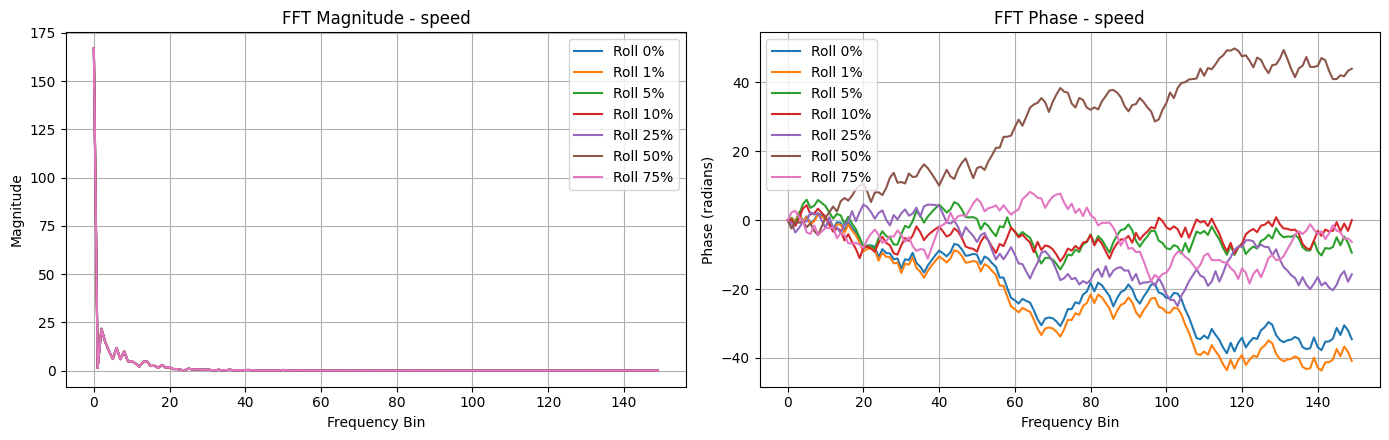

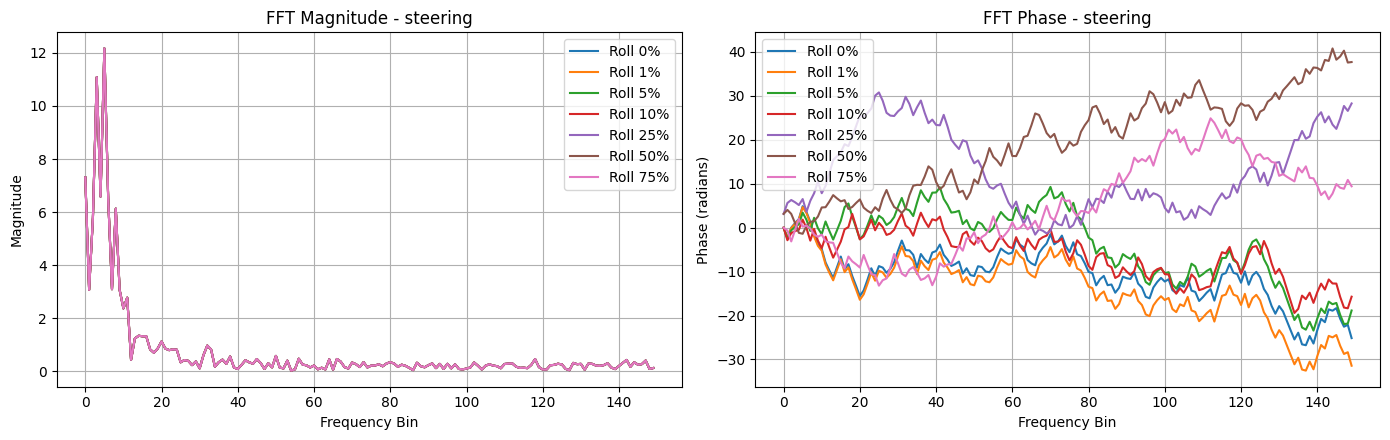

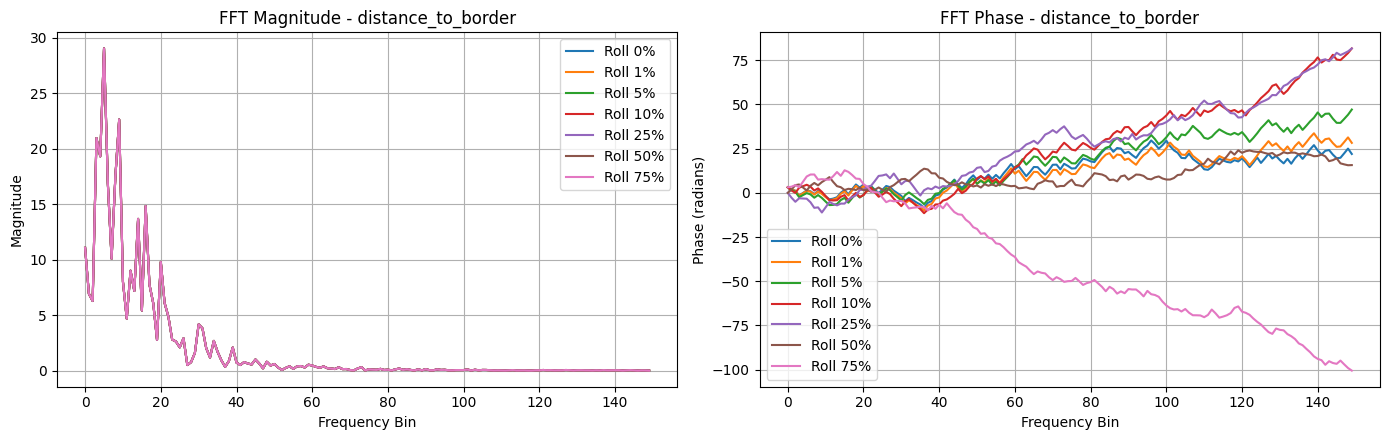

In [21]:
print("cleaned_metrics shape:", cleaned_metrics.shape)

if cleaned_metrics.ndim != 3 or cleaned_metrics.shape[2] != 3:
    raise ValueError(
        f"Expected cleaned_metrics with shape (num_signals, timesteps, 3), got {cleaned_metrics.shape}"
    )

dimension_names = ["speed", "steering", "distance_to_border"]

# For each metric, show magnitude and phase side by side
for dim_idx, dim_name in enumerate(dimension_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
    ax_mag, ax_phase = axes

    for signal_idx, metrics in enumerate(cleaned_metrics):
        signal = metrics[:, dim_idx]
        spectrum = np.fft.rfft(signal)

        fft_mag = np.abs(spectrum)
        fft_phase = np.unwrap(np.angle(spectrum))

        label = f"Roll {int(roll_percents[signal_idx] * 100)}%"
        ax_mag.plot(fft_mag, label=label)
        ax_phase.plot(fft_phase, label=label)

    ax_mag.set_title(f"FFT Magnitude - {dim_name}")
    ax_mag.set_xlabel("Frequency Bin")
    ax_mag.set_ylabel("Magnitude")
    ax_mag.grid(True)
    ax_mag.legend()

    ax_phase.set_title(f"FFT Phase - {dim_name}")
    ax_phase.set_xlabel("Frequency Bin")
    ax_phase.set_ylabel("Phase (radians)")
    ax_phase.grid(True)
    ax_phase.legend()

    fig.tight_layout()
    plt.show()